<a href="https://colab.research.google.com/github/COMP4702-UQ/Pracs-notebook/blob/main/PracW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 - Supervised Learning (k-NN and Decision Trees)

## Import library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Q1

In [5]:
# Load dataset
w3regr = pd.read_csv('./w3regr.csv', header=None)
w3classif = pd.read_csv('./w3classif.csv', header=None)

# Rename columns
w3regr.columns = ['x', 'y']
w3classif.columns = ['x1', 'x2', 'label']

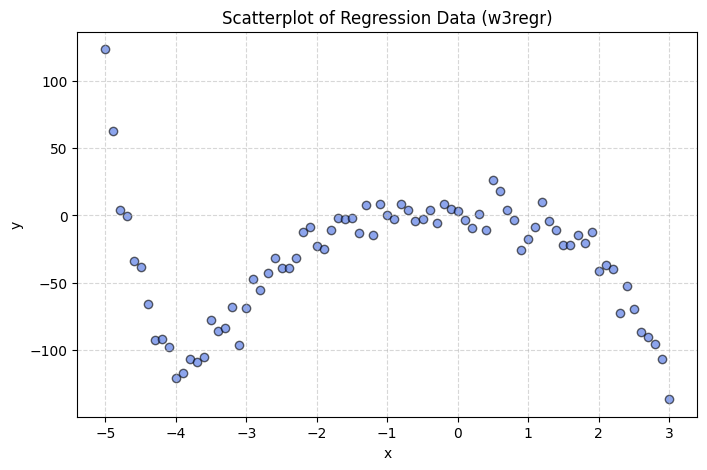

In [6]:
# TODO: Visualize w3regr
plt.figure(figsize=(8, 5))
plt.scatter(w3regr['x'], w3regr['y'], alpha=0.6, color='royalblue', edgecolors='k')
plt.title('Scatterplot of Regression Data (w3regr)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

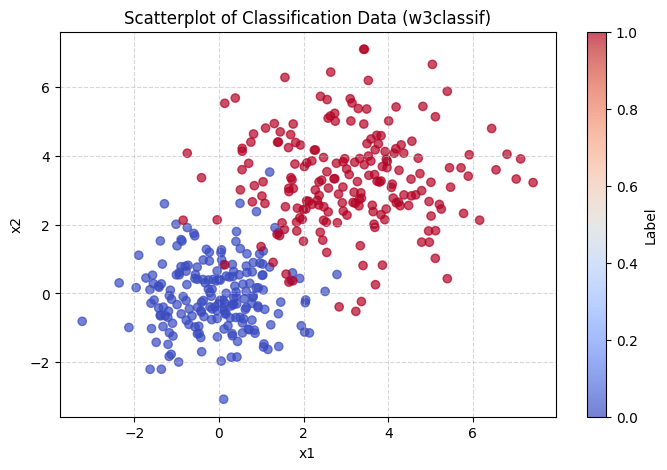

In [7]:
# TODO: Visualize w3classif
plt.figure(figsize=(8, 5))
# Using 'c' to color by label and 'cmap' for the color scheme
scatter = plt.scatter(w3classif['x1'], w3classif['x2'], c=w3classif['label'], cmap='coolwarm', alpha=0.7)
plt.title('Scatterplot of Classification Data (w3classif)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.colorbar(scatter, label='Label') # Adds a legend for the colors
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Q2

In [ ]:
from sklearn.model_selection import train_test_split
seed = 42

# TODO: Randomly shuffle w3classif
...

# TODO: Split w3classif
...

## Q3

### (a)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# TODO: Split to X (input_features) and y (label) into training and testing sets
X_train, y_train = ...
X_test, y_test = ...

In [ ]:
# TODO: Initialize the k-NN classifier with k = 3
knn_classifier = ...

# TODO: Train the classifier on the training data

# TODO: Make predictions on the training and test data

# TODO: Calculate training and test accuracy
train_accuracy = ...
test_accuracy = ...

# TODO: Calculate training and test loss (misclassification rate)
train_loss = ...
test_loss = ...

# Display results
print(f'Training Accuracy: {train_accuracy * 100:.2f}%')
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')

print(f'Training Loss (Misclassification Rate): {train_loss * 100:.2f}%')
print(f'Test Loss (Misclassification Rate): {test_loss * 100:.2f}%')

### (b)

In [ ]:
from matplotlib.colors import ListedColormap
import numpy as np

# Plot decision regions
def plot_decision_regions(X, y, classifier, resolution=0.02):
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # TODO: Generate grid of points
    ...

    # TODO: Predicting labels for grid of points
    ...

    # TODO: Plot contour
    ...

    # TODO: Plot training points
    ...

In [ ]:
# Plot decision regions and data points
plt.figure(figsize=(10, 8))
plot_decision_regions(X_train.values, y_train.values, knn_classifier)
plt.title('Decision Regions for k-NN Classifier (Training Data)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='upper right')
plt.show()

### (c)

In [ ]:
# Experiment with different k values
k_values = [1, 3, 5, 7]

plt.figure(figsize=(12, 9))

for i, k in enumerate(k_values, 1):
    # TODO: Initialize the k-NN classifier with the current k value
    knn_classifier = ...

    # TODO: Train the classifier on the training data
    ...

    # TODO: Make predictions on the test data
    ...

    # TODO: Calculate accuracy and loss
    ...

    # TODO: Plot decision regions
    ...

plt.tight_layout()
plt.show()

## Q5

### (a)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# TODO: Initialize the Decision Tree classifier
decision_tree_classifier = ...

# TODO: Train the classifier on the training data
...

# TODO: Make predictions on the training and test data
...

# TODO: Calculate training and test accuracy
...

# TODO: Calculate training and test loss (misclassification rate)
...

# Display results
print(f'Training Accuracy: {train_accuracy * 100:.2f}%')
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')

print(f'Training Loss (Misclassification Rate): {train_loss * 100:.2f}%')
print(f'Test Loss (Misclassification Rate): {test_loss * 100:.2f}%')

### (b)

In [ ]:
# TODO: Plot decision regions and data points (hint: re-use the 'plot_decision_regions' function)
...

### (c)

In [ ]:
# Experiment with different maximum depth values
max_depth_values = [None, 3, 5, 100]

plt.figure(figsize=(12, 9))

for i, max_depth in enumerate(max_depth_values, 1):
    # TODO: Initialize the Decision Tree classifier with the current maximum depth value
    decision_tree_classifier = ...

    # TODO: Train the classifier on the training data
    ...

    # TODO: Make predictions on the test data
    ...

    # TODO: Calculate accuracy and loss
    ...

    # TODO: Plot decision regions
    ...

plt.tight_layout()
plt.show()

## BONUS EXERCISE:

In the previous part of the assignment, you used the `scikit-learn` API to train and evaluate models such as K-Nearest Neighbors and Decision Trees. While these implementations are efficient and convenient, they abstract away the core mechanics of how the algorithms actually work.

This bonus exercise invites you to go one level deeper.

Your task is to implement **KNN** and a **Decision Tree classifier** <u>from scratch in Python</u>, while keeping the same input–output format as `scikit-learn` (i.e., `fit(X, y)` and `predict(X)` with `X` shaped `(n_samples, n_features)` and `y` shaped `(n_samples,))`.

**The goal is not to compete with the highly optimized implementations in scikit-learn, but to understand the algorithmic logic behind models such as KNeighborsClassifier and DecisionTreeClassifier.**

By completing this exercise, you will:

- Strengthen your understanding of distance metrics and majority voting in KNN

- Understand how impurity measures such as Gini index guide tree splitting

- See how recursive tree construction works in practice

- Appreciate the design of clean, reusable ML APIs

- Develop deeper intuition about computational complexity and efficiency

This exercise is optional but highly recommended for students who want a stronger grasp of how machine learning models operate internally rather than treating them as black boxes.

Think of it as lifting the hood of a well-engineered system and rebuilding a simplified version yourself.

### B1 - From-scratch KNN

In [ ]:
class KNeighborsClassifier:
    def __init__(self, n_neighbors=3):
        """
        Parameters
        ----------
        n_neighbors : int
            Number of nearest neighbors to use.
        """
        self.k = n_neighbors

    def fit(self, X, y):
        """
        Store the training data.

        Parameters
        ----------
        X : shape (n_samples, n_features)
        y : shape (n_samples,)
        """

        # TODO:
        # Convert X and y to NumPy arrays
        # Store them as instance variables (e.g., self.X_train, self.y_train)

        return self

    def _euclidean_distance(self, x1, x2):
        """
        Compute Euclidean distance between two vectors.

        Formula:
            sqrt(sum((x1 - x2)^2))

        Steps:
        1. Subtract vectors
        2. Square elementwise
        3. Sum all elements
        4. Take square root

        TODO:
        - Implement distance calculation
        """
        pass

    def predict(self, X):
        """
        Predict labels for multiple samples.

        Parameters
        ----------
        X : shape (n_samples, n_features)

        Returns
        -------
        predictions : shape (n_samples,)
        """

        # TODO:
        # Convert X to NumPy array

        # TODO:
        # For each sample in X:
        #   - Call _predict_one(x)
        #   - Store predictions in a list

        # TODO:
        # Convert predictions list to NumPy array
        # Return it

        pass

    def _predict_one(self, x):
        """
        Predict label for a single sample.

        Steps:
        1. Compute distance between x and ALL training points
        2. Find indices of k smallest distances
        3. Get labels of those k neighbors
        4. Return majority class

        Questions to think about:
        - Why do we sort distances?
        - What happens if there is a tie?
        """

        # TODO:
        # Compute distances to every training point
        # (Hint: loop over self.X_train)

        # TODO:
        # Use np.argsort(distances) to get sorted indices

        # TODO:
        # Select first k indices

        # TODO:
        # Retrieve labels using those indices

        # TODO:
        # Use Counter to find most common label

        pass

In [ ]:
# TODO: Q3b
knn_classifier = KNeighborsClassifier(n_neighbors=3)
...

In [ ]:
# Plot decision regions and data points
plt.figure(figsize=(10, 8))
plot_decision_regions(X_train.values, y_train.values, knn_classifier)
plt.title('Decision Regions for k-NN Classifier (Training Data)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='upper right')
plt.show()

In [ ]:
# TODO: Q3c

### B2 - From-scratch Decision Tree

In [ ]:
import numpy as np


class DecisionTreeClassifier:
    def __init__(self, max_depth=None, min_samples_split=2, random_state=None):
        """
        Parameters
        ----------
        max_depth : int or None
            Maximum depth of the tree.
        min_samples_split : int
            Minimum number of samples required to split.
        random_state : int or None
            Random seed for reproducibility.
        """
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.random_state = random_state
        self.tree_ = None

        # TODO:
        # If random_state is not None, set NumPy random seed.


    class Node:
        """
        A single node in the decision tree.

        For internal nodes:
            - feature: index of feature used for split
            - threshold: threshold value
            - left: left child node
            - right: right child node

        For leaf nodes:
            - value: predicted class
        """
        def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
            self.feature = feature
            self.threshold = threshold
            self.left = left
            self.right = right
            self.value = value


    def _gini(self, y):
        """
        Compute Gini impurity of labels y.

        Gini = 1 - sum(p_k^2)

        Steps:
        1. Count occurrences of each class
        2. Convert counts to probabilities
        3. Apply formula

        TODO:
        - Implement this function
        """
        pass


    def _best_split(self, X, y):
        """
        Find the best feature and threshold to split the data.

        Steps:
        1. Loop over each feature
        2. For each feature:
            - Get candidate thresholds (e.g., unique values)
        3. For each threshold:
            - Split data into left and right
            - Skip if one side is empty
            - Compute weighted Gini impurity
        4. Keep track of the split with lowest impurity

        Return
        ------
        best_feature, best_threshold
        """

        n_samples, n_features = X.shape

        # TODO:
        # Initialize variables to store best impurity and split
        # Example:
        # best_gini = ...
        # best_feature = ...
        # best_threshold = ...

        # TODO:
        # Loop over features and thresholds
        # Compute weighted Gini
        # Update best split when improvement found

        return None, None  # Replace with actual best split


    def _build_tree(self, X, y, depth):
        """
        Recursively build the tree.

        Stopping conditions:
        - Only one class remains
        - Number of samples < min_samples_split
        - depth >= max_depth (if max_depth is not None)

        Steps:
        1. Check stopping conditions
            -> If true, return leaf node
        2. Find best split
            -> If no valid split, return leaf node
        3. Split data
        4. Recursively build left and right subtrees
        5. Return internal node
        """

        n_samples = X.shape[0]
        n_classes = len(np.unique(y))

        # TODO:
        # Implement stopping condition
        # If stopping condition met:
        #   - Compute majority class
        #   - Return leaf node

        # TODO:
        # Find best split using _best_split()

        # TODO:
        # If no split found:
        #   - Return leaf node

        # TODO:
        # Create masks for left and right split

        # TODO:
        # Recursively build left and right subtrees

        # TODO:
        # Return Node(feature, threshold, left_subtree, right_subtree)

        pass


    def fit(self, X, y):
        """
        Train the decision tree.

        Steps:
        1. Convert X and y to NumPy arrays
        2. Call _build_tree starting at depth 0
        3. Store the result in self.tree_
        """

        # TODO:
        # Convert inputs to NumPy arrays

        # TODO:
        # Build tree

        return self


    def _predict_one(self, x, node):
        """
        Predict the class for a single sample.

        Steps:
        - If node is leaf -> return node.value
        - Else:
            - Check feature index
            - Compare x[feature] with threshold
            - Recurse into left or right subtree
        """

        # TODO:
        # Implement recursive traversal

        pass


    def predict(self, X):
        """
        Predict labels for multiple samples.

        Steps:
        1. Convert X to NumPy array
        2. For each sample, call _predict_one
        3. Return predictions as NumPy array
        """

        # TODO:
        # Implement batch prediction

        pass

In [ ]:
# Q5a
decision_tree_classifier = DecisionTreeClassifier(random_state=42)

In [ ]:
# Q5b
plt.figure(figsize=(10, 8))
plot_decision_regions(X_train.values, y_train.values, decision_tree_classifier)
plt.title('Decision Regions for k-NN Classifier (Training Data)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='upper right')
plt.show()

In [ ]:
# Q5c